In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import sys
sys.path.append(r'\\192.168.10.106\imdea\DataDriven_UT_AlbertoVicente\10_code\UTvsXCT-preprocessing')
sys.path.append(r'/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/10_code/UTvsXCT-preprocessing')

from preprocess_tools import aligner,onlypores,io,pore_filtering,reslicer

In [2]:
# Enhanced Professional Plot Theme Configuration
# Color palette: #4281a4 (primary blue), #4c3b4d (deep purple), #48a9a6 (teal), #e4dfda (light beige), #e980fc (magenta)

def apply_plot_theme():
    """Apply the enhanced professional plot theme to current figure"""
    fig = plt.gcf()
    ax = plt.gca()
    
    # Set figure size and colors
    fig.set_size_inches(10, 6)
    fig.patch.set_facecolor('#f8f6f4')  # Slightly warmer white background
    ax.set_facecolor('#fdfcfb')  # Very light warm background for plot area
    
    # Configure enhanced grid
    ax.grid(True, axis='y', alpha=0.4, color='#e4dfda', linewidth=0.8, linestyle='-')
    ax.grid(True, axis='x', alpha=0.2, color='#e4dfda', linewidth=0.5, linestyle=':')
    ax.set_axisbelow(True)
    
    # Enhanced text styling with better contrast
    ax.tick_params(colors='#4c3b4d', labelsize=11, width=1.2)  # Deep purple tick labels
    ax.xaxis.label.set_color('#4c3b4d')  # Deep purple for better readability
    ax.yaxis.label.set_color('#4c3b4d')  # Deep purple for better readability
    ax.xaxis.label.set_fontsize(13)
    ax.yaxis.label.set_fontsize(13)
    ax.xaxis.label.set_fontweight('medium')
    ax.yaxis.label.set_fontweight('medium')
    
    # Enhanced spine styling
    for spine in ax.spines.values():
        spine.set_color('#4c3b4d')
        spine.set_linewidth(1.3)
        spine.set_alpha(0.8)
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Enhanced legend styling
    legend = ax.get_legend()
    if legend:
        legend.get_frame().set_facecolor('#fdfcfb')
        legend.get_frame().set_edgecolor('#4c3b4d')
        legend.get_frame().set_linewidth(1.2)
        legend.get_frame().set_alpha(0.95)
        for text in legend.get_texts():
            text.set_color('#4c3b4d')
            text.set_fontsize(11)
            text.set_fontweight('medium')
        # Add subtle shadow to legend
        legend.get_frame().set_boxstyle("round,pad=0.5")
    
    # Enhanced layout with better spacing
    plt.tight_layout(pad=2.5)
    
    # Subtle border around the entire plot
    fig.patch.set_linewidth(1)
    fig.patch.set_edgecolor('#e4dfda')

In [3]:
#load the onlypores to filter

file_path = Path(r"/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/02_XCT_data/Juan Ignacio/probetas/7/volume_eq_aligned.tif")

volume = io.load_tif(file_path)

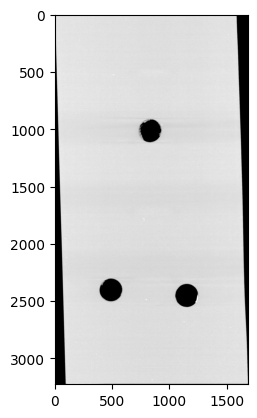

In [4]:
plt.imshow(volume.max(axis=0), cmap='gray')

In [5]:
volume  = reslicer.rotate_90(volume,False)
volume = reslicer.reslice(volume,'Right')

#get the frontwall and backwall of the xct volume
_,frontwall,backwall = aligner.crop_walls(volume)

volume = reslicer.reslice(volume,'Left')
volume  = reslicer.rotate_90(volume,True)

print(frontwall, backwall)

Computing material mask using sequential processing...
Filling internal voids...
Material mask generation complete.
8 172


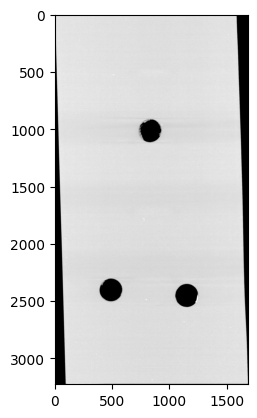

In [6]:
plt.imshow(volume.max(axis=0), cmap='gray')

In [7]:
onlypores_volume,sample_mask,binary = onlypores.onlypores(volume,frontwall=frontwall, backwall=backwall, min_size_filtering=8)

Starting pore detection analysis...
Computing volume bounding box...
Original volume shape: (196, 3227, 1685)
Data bounding box: Z[0:195], Y[0:3226], X[0:1684]
Cropped volume shape: (196, 3227, 1685)
Applying Sauvola adaptive thresholding...
Volume size: 0.99 GB
Available memory: 201.69 GB
Required memory estimate: 1.99 GB
Using parallel implementation...
Window size adjusted to 31 (must be odd)
Applying Sauvola thresholding with parallel processing...
Excluding front wall: slices 0 to 7
Excluding back wall: slices 172 to end
Generating material mask...
Computing material mask using sequential processing...
Filling internal voids...
Material mask generation complete.
Initial pore detection complete. Found 4533212 pore voxels.
Applying pore filtering with minimum size: 8
Cleaning pores with min_size=8...
  Initial connected components: 89242


/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/10_code/UTvsXCT-preprocessing/preprocess_tools/onlypores.py:512: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  labeled_pores = remove_small_objects(labeled_pores, min_size=min_size, connectivity=3)


  Components after size filtering: 2200
  Valid components after dimensional filtering: 2023
  Components after dimensional filtering: 2023
  Total pore voxels retained: 4372615
After filtering: 4372615 pore voxels remaining.
Pore detection analysis complete.


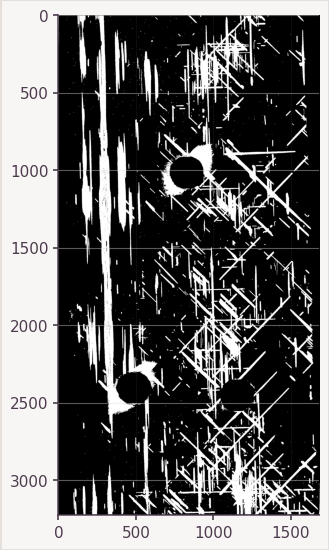

In [8]:
plt.imshow(onlypores_volume.max(axis=0), cmap='gray')
apply_plot_theme()

# Void Volumetric Fraction

In [9]:
pores_count = np.count_nonzero(onlypores_volume, axis=(0))
material_count = np.count_nonzero(sample_mask, axis=(0))

non_valid_idxs = material_count == 0

total_vvf = np.sum(pores_count) / np.sum(material_count)
print(f'Total VVF: {total_vvf*100:.2f} %')

Total VVF: 0.50 %


In [10]:
vvf_projection = pores_count / material_count
vvf_projection[non_valid_idxs] = 0
vvf_projection[vvf_projection > 0.06] = 0  # Cap VVF at 1 for visualization purposes

/tmp/ipykernel_237491/2868931500.py:1: RuntimeWarning: invalid value encountered in divide
  vvf_projection = pores_count / material_count


In [11]:
figures_folder = Path(r'/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/00_literature/05_Alberto_Vicente/01_FYA/First_Year/Figures')

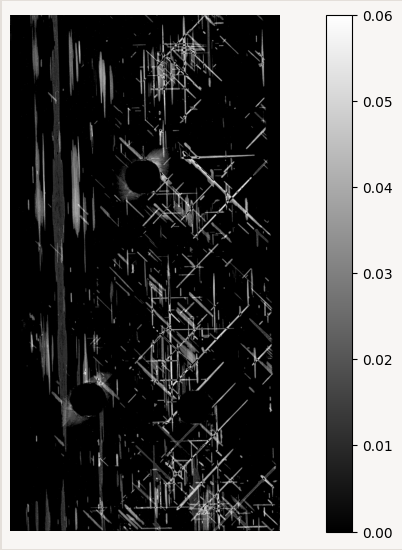

In [12]:
plt.imshow(vvf_projection, cmap='gray')
plt.colorbar()
plt.axis('off')
apply_plot_theme()
plt.savefig(figures_folder / 'vvf_projection.pdf', bbox_inches='tight', dpi=300)

In [13]:
total_material_zone = backwall - frontwall
material_half = (total_material_zone // 2) + frontwall
material_half

90

/tmp/ipykernel_237491/784859378.py:3: RuntimeWarning: invalid value encountered in divide
  vvf_projection_first_half = pores_count_first_half / material_count_first_half


Total VVF (first half): 0.59 %


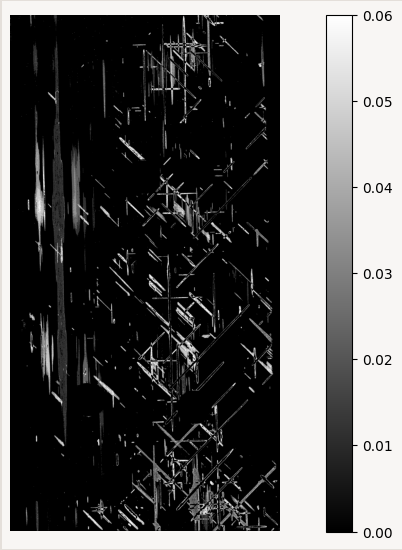

In [14]:
pores_count_first_half = np.count_nonzero(onlypores_volume[:material_half,:, :], axis=(0))
material_count_first_half = np.count_nonzero(sample_mask[:material_half,:, :], axis=(0))
vvf_projection_first_half = pores_count_first_half / material_count_first_half
vvf_projection_first_half[material_count_first_half == 0] = 0
vvf_projection_first_half[vvf_projection_first_half > 0.06] = 0
print(f'Total VVF (first half): {np.sum(pores_count_first_half) / np.sum(material_count_first_half)*100:.2f} %')
plt.imshow(vvf_projection_first_half, cmap='gray')
plt.colorbar()
plt.axis('off')
apply_plot_theme()
plt.savefig(figures_folder / 'vvf_projection_first_half.pdf', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_237491/1957317665.py:3: RuntimeWarning: invalid value encountered in divide
  vvf_projection_second_half = pores_count_second_half / material_count_second_half


Total VVF (second half): 0.42 %


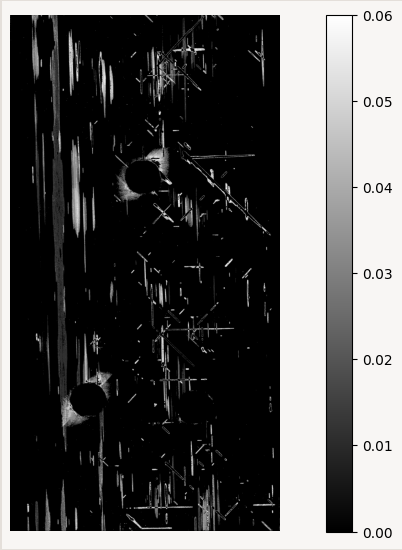

In [15]:
pores_count_second_half = np.count_nonzero(onlypores_volume[material_half:, :, :], axis=(0))
material_count_second_half = np.count_nonzero(sample_mask[material_half:, :, :], axis=(0))
vvf_projection_second_half = pores_count_second_half / material_count_second_half
vvf_projection_second_half[material_count_second_half == 0] = 0
vvf_projection_second_half[vvf_projection_second_half > 0.06] = 0
print(f'Total VVF (second half): {np.sum(pores_count_second_half) / np.sum(material_count_second_half)*100:.2f} %')
plt.imshow(vvf_projection_second_half, cmap='gray')
plt.colorbar()
plt.axis('off')
apply_plot_theme()
plt.savefig(figures_folder / 'vvf_projection_second_half.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Pores morphology

In [23]:
import skimage.measure

labeled_pores, num_features = skimage.measure.label(onlypores_volume, return_num=True, connectivity=3)
print(f'Number of pores detected: {num_features}')

Number of pores detected: 2023


In [27]:
import numpy as np

def pore_eigenvalues_fast(label_volume, min_voxels=0):
    """
    Efficient per-pore covariance eigenvalues from a 3D labeled volume.

    Uses bounding boxes (via scipy.ndimage.find_objects) to avoid scanning the full
    volume for every label.

    Parameters
    ----------
    label_volume : np.ndarray (3D, int)
        Labeled volume (0 = background, 1..N = pores).
        Labels do NOT need to be contiguous, but must be positive ints.
    min_voxels : int
        Skip pores smaller than this voxel count.

    Returns
    -------
    labels_out : np.ndarray, shape (M,)
        Labels kept (>= min_voxels).
    eigvals_out : np.ndarray, shape (M, 3)
        Eigenvalues [lambda1, lambda2, lambda3] sorted descending per pore.
        These are eigenvalues of the coordinate covariance matrix (units: voxel^2).
    """
    try:
        from scipy import ndimage as ndi
    except ImportError as e:
        raise ImportError(
            "pore_eigenvalues_fast requires scipy. Install with: pip install scipy"
        ) from e

    # Find bounding boxes for labels 1..max_label
    max_label = int(label_volume.max())
    if max_label == 0:
        return np.array([], dtype=int), np.empty((0, 3), dtype=np.float64)

    slices = ndi.find_objects(label_volume, max_label=max_label)

    labels_out = []
    eigvals_out = []

    for lbl, slc in enumerate(slices, start=1):
        if slc is None:
            continue  # label missing

        sub = label_volume[slc]
        mask = (sub == lbl)
        n = int(mask.sum())
        if n < min_voxels:
            continue

        # Local coords within bounding box, then shift to global coords
        coords = np.argwhere(mask).astype(np.float64)
        coords[:, 0] += slc[0].start
        coords[:, 1] += slc[1].start
        coords[:, 2] += slc[2].start

        # Covariance of coordinates
        centroid = coords.mean(axis=0)
        centered = coords - centroid
        C = (centered.T @ centered) / n  # 3x3, symmetric

        # Eigenvalues of symmetric matrix, ascending -> reverse for descending
        w = np.linalg.eigvalsh(C)[::-1]

        labels_out.append(lbl)
        eigvals_out.append(w)

    return np.asarray(labels_out, dtype=int), np.vstack(eigvals_out) if eigvals_out else np.empty((0, 3), dtype=np.float64)

eigen_labels, eigenvalues = pore_eigenvalues_fast(labeled_pores, min_voxels=8)

In [28]:
def pore_morphology_analysis(label_volume, min_voxels=10):
    """
    Compute comprehensive morphological properties for each pore.
    
    Parameters
    ----------
    label_volume : np.ndarray (3D, int)
        Labeled volume (0 = background, 1..N = pores).
    min_voxels : int
        Skip pores smaller than this voxel count.
    
    Returns
    -------
    results : dict
        Dictionary containing:
        - 'labels': pore labels (M,)
        - 'volumes': voxel counts (M,)
        - 'areas_xy': projected area in XY plane (pixels) (M,)
        - 'eigenvalues': sorted eigenvalues [λ1, λ2, λ3] descending (M, 3)
        - 'sphericity': sphericity metric (M,)
        - 'elongation': elongation metric (M,)
        - 'flatness': flatness metric (M,)
        - 'orientation': angle with Z axis in degrees [0°, 90°] (M,)
            0° = aligned with Z, 90° = perpendicular to Z
    """
    try:
        from scipy import ndimage as ndi
    except ImportError as e:
        raise ImportError(
            "pore_morphology_analysis requires scipy. Install with: pip install scipy"
        ) from e
    
    max_label = int(label_volume.max())
    if max_label == 0:
        return {
            'labels': np.array([], dtype=int),
            'volumes': np.array([], dtype=int),
            'areas_xy': np.array([], dtype=int),
            'eigenvalues': np.empty((0, 3), dtype=np.float64),
            'sphericity': np.array([], dtype=np.float64),
            'elongation': np.array([], dtype=np.float64),
            'flatness': np.array([], dtype=np.float64),
            'orientation': np.empty((0, 3), dtype=np.float64)
        }
    
    slices = ndi.find_objects(label_volume, max_label=max_label)
    
    labels_out = []
    volumes_out = []
    areas_xy_out = []
    eigvals_out = []
    sphericity_out = []
    elongation_out = []
    flatness_out = []
    orientation_out = []
    
    for lbl, slc in enumerate(slices, start=1):
        if slc is None:
            continue
        
        sub = label_volume[slc]
        mask = (sub == lbl)
        n = int(mask.sum())
        if n < min_voxels:
            continue
        
        # Get coordinates
        coords = np.argwhere(mask).astype(np.float64)
        coords[:, 0] += slc[0].start
        coords[:, 1] += slc[1].start
        coords[:, 2] += slc[2].start
        
        # Compute area in XY plane (projection along Z axis)
        # Since axes order is (Z,Y,X), we need unique (Y,X) pairs
        coords_yx = coords[:, 1:].astype(int)  # Get Y,X coordinates
        unique_yx = np.unique(coords_yx, axis=0)
        area_xy = len(unique_yx)
        
        # Covariance matrix
        centroid = coords.mean(axis=0)
        centered = coords - centroid
        C = (centered.T @ centered) / n
        
        # Eigenvalues and eigenvectors (sorted ascending by default)
        w, v = np.linalg.eigh(C)
        
        # Sort descending: λ1 >= λ2 >= λ3
        idx = np.argsort(w)[::-1]
        w = w[idx]
        v = v[:, idx]
        
        # Shape metrics
        λ1, λ2, λ3 = w[0], w[1], w[2]
        
        # Avoid division by zero
        eps = 1e-12
        
        # Sphericity: λ3/λ1 (ranges from 0 to 1, 1 = perfect sphere)
        sphericity = λ3 / (λ1 + eps)
        
        # Elongation: λ2/λ1 (ranges from 0 to 1)
        elongation = λ2 / (λ1 + eps)
        
        # Flatness: λ3/λ2 (ranges from 0 to 1)
        flatness = λ3 / (λ2 + eps)
        
        # Orientation: angle with respect to Z axis (first dimension in z,x,y system)
        principal_axis = v[:, 0]
        z_axis = np.array([1.0, 0.0, 0.0])  # Z axis in (z,x,y) system
        cos_angle = np.abs(np.dot(principal_axis, z_axis))  # |cos(θ)|
        angle_rad = np.arccos(np.clip(cos_angle, 0, 1))  # Angle in radians [0, π/2]
        angle_deg = np.degrees(angle_rad)  # Angle in degrees [0, 90]
        
        labels_out.append(lbl)
        volumes_out.append(n)
        areas_xy_out.append(area_xy)
        eigvals_out.append(w)
        sphericity_out.append(sphericity)
        elongation_out.append(elongation)
        flatness_out.append(flatness)
        orientation_out.append(angle_deg)
    
    return {
        'labels': np.asarray(labels_out, dtype=int),
        'volumes': np.asarray(volumes_out, dtype=int),
        'areas_xy': np.asarray(areas_xy_out, dtype=int),
        'eigenvalues': np.vstack(eigvals_out) if eigvals_out else np.empty((0, 3), dtype=np.float64),
        'sphericity': np.asarray(sphericity_out, dtype=np.float64),
        'elongation': np.asarray(elongation_out, dtype=np.float64),
        'flatness': np.asarray(flatness_out, dtype=np.float64),
        'orientation': np.asarray(orientation_out, dtype=np.float64)  # Angle with Z axis in degrees [0, 90]
    }

# Compute all morphological properties
pore_props = pore_morphology_analysis(labeled_pores, min_voxels=8)

print(f"Analyzed {len(pore_props['labels'])} pores")
print(f"\nSummary statistics:")
print(f"Volume (voxels):   mean={pore_props['volumes'].mean():.1f}, std={pore_props['volumes'].std():.1f}")
print(f"Area XY (pixels):  mean={pore_props['areas_xy'].mean():.1f}, std={pore_props['areas_xy'].std():.1f}")
print(f"Sphericity:        mean={pore_props['sphericity'].mean():.3f}, std={pore_props['sphericity'].std():.3f}")
print(f"Elongation:        mean={pore_props['elongation'].mean():.3f}, std={pore_props['elongation'].std():.3f}")
print(f"Flatness:          mean={pore_props['flatness'].mean():.3f}, std={pore_props['flatness'].std():.3f}")

Analyzed 2023 pores

Summary statistics:
Volume (voxels):   mean=2161.5, std=10644.1
Area XY (pixels):  mean=581.8, std=3436.3
Sphericity:        mean=0.088, std=0.115
Elongation:        mean=0.220, std=0.226
Flatness:          mean=0.392, std=0.231


## Morphological Characteristics of Pores

The morphological analysis computes several key characteristics for each detected pore in the 3D volume:

### Geometric Properties

**Volume**: The total number of voxels occupied by each pore. This provides a direct measure of pore size in the discretized volume.

**Area XY**: The projected area of the pore onto the XY plane (perpendicular to the Z axis). This is computed as the number of unique (Y, X) coordinate pairs occupied by the pore, representing the pore's footprint when viewed from above.

### Shape Descriptors via Eigenvalue Analysis

The shape characteristics are derived from the eigenvalues (λ₁ ≥ λ₂ ≥ λ₃) of the spatial covariance matrix of each pore's voxel coordinates. These eigenvalues represent the variance along the three principal axes of the pore and provide insight into its 3D geometry:

**Sphericity** (λ₃/λ₁): Ratio of the smallest to largest eigenvalue. Ranges from 0 to 1, where values close to 1 indicate a spherical shape, while values near 0 suggest highly elongated or flat structures.

**Elongation** (λ₂/λ₁): Ratio of the middle to largest eigenvalue. Values close to 1 indicate that the pore extends similarly in its two largest dimensions, while lower values suggest elongation along a single dominant axis.

**Flatness** (λ₃/λ₂): Ratio of the smallest to middle eigenvalue. Values near 0 indicate a flat, pancake-like structure, while values close to 1 suggest the pore has similar extent in all directions except the principal axis.

### Spatial Orientation

**Orientation**: The angle (in degrees, ranging from 0° to 90°) between the pore's principal axis (eigenvector corresponding to λ₁) and the Z axis. An angle of 0° indicates the pore is aligned with the Z direction, while 90° indicates it lies perpendicular to the Z axis in the XY plane.

These metrics collectively characterize the size, shape, and orientation of each pore, enabling quantitative analysis of the void structure within the material.

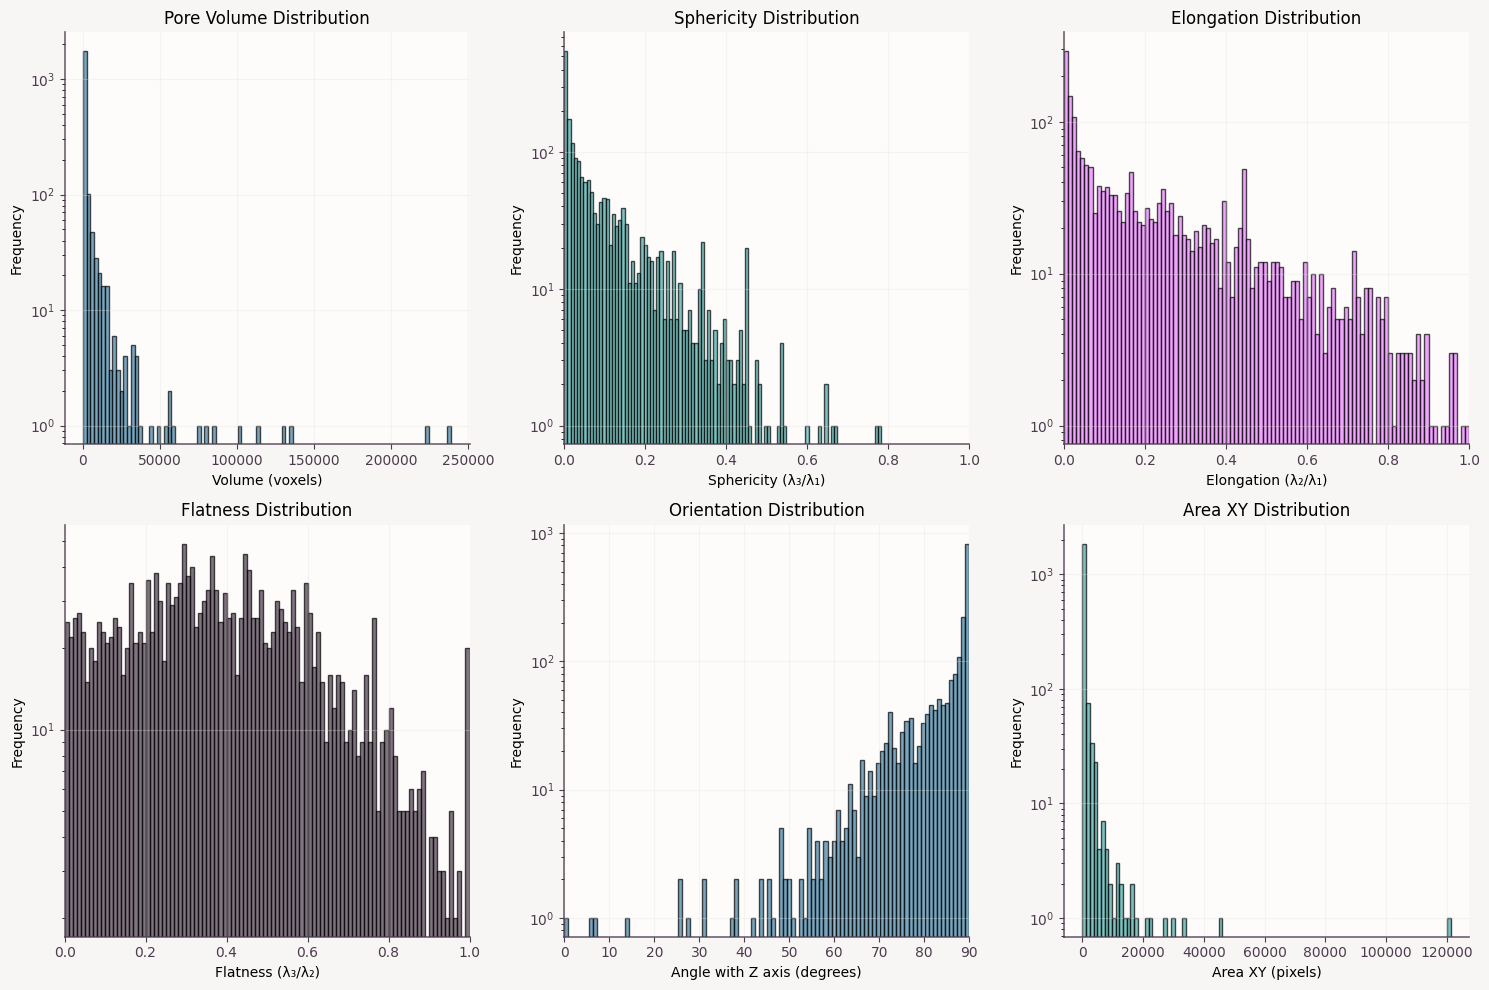

In [30]:
# Visualize morphological property distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Volume distribution
axes[0, 0].hist(pore_props['volumes'], bins=100, color='#4281a4', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Volume (voxels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Pore Volume Distribution')
axes[0, 0].set_yscale('log')

# Sphericity distribution
axes[0, 1].hist(pore_props['sphericity'], bins=100, color='#48a9a6', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Sphericity (λ₃/λ₁)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Sphericity Distribution')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].set_yscale('log')

# Elongation distribution
axes[0, 2].hist(pore_props['elongation'], bins=100, color='#e980fc', alpha=0.7, edgecolor='black')
axes[0, 2].set_xlabel('Elongation (λ₂/λ₁)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Elongation Distribution')
axes[0, 2].set_xlim([0, 1])
axes[0, 2].set_yscale('log')

# Flatness distribution
axes[1, 0].hist(pore_props['flatness'], bins=100, color='#4c3b4d', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Flatness (λ₃/λ₂)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Flatness Distribution')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_yscale('log')

# Orientation distribution (angle with Z axis)
axes[1, 1].hist(pore_props['orientation'], bins=100, color='#4281a4', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Angle with Z axis (degrees)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Orientation Distribution')
axes[1, 1].set_xlim([0, 90])
axes[1, 1].set_yscale('log')

# Area XY distribution
axes[1, 2].hist(pore_props['areas_xy'], bins=100, color='#48a9a6', alpha=0.7, edgecolor='black')
axes[1, 2].set_xlabel('Area XY (pixels)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Area XY Distribution')
axes[1, 2].set_yscale('log')

# Apply theme to all subplots
for ax in axes.flat:
    ax.grid(True, alpha=0.3, color='#e4dfda', linewidth=0.8)
    ax.set_facecolor('#fdfcfb')
    ax.tick_params(colors='#4c3b4d', labelsize=10)
    for spine in ax.spines.values():
        spine.set_color('#4c3b4d')
        spine.set_linewidth(1.2)
        spine.set_alpha(0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.patch.set_facecolor('#f8f6f4')
plt.tight_layout()
plt.savefig(figures_folder / 'pore_morphology_distributions.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Pore Location

## Void Volumetric Fraction Profile Along Z Axis

This analysis examines how porosity varies through the depth of the material by computing the **Volumetric Void Fraction (VVF)** at each position along the Z axis.

### Methodology

For each Z position (slice perpendicular to the Z axis):
1. Count the number of pore voxels in that slice
2. Count the total number of material voxels (sample mask) in that slice
3. Compute the local VVF as the ratio: **VVF(z) = pore_voxels(z) / material_voxels(z)**

### Interpretation

The resulting **VVF profile** reveals:
- **Spatial distribution of porosity**: Whether voids are uniformly distributed or concentrated in specific regions
- **Manufacturing artifacts**: Potential identification of pore accumulation near surfaces or interfaces
- **Depth-dependent effects**: Changes in porosity through the material thickness that may result from processing conditions (e.g., resin flow, degassing, curing gradients)

This profile is particularly valuable for understanding:
- Layer-by-layer quality in additive manufacturing or laminated composites
- Gradient effects in materials with varying consolidation or compaction
- Identification of critical zones with elevated porosity that may affect mechanical performance

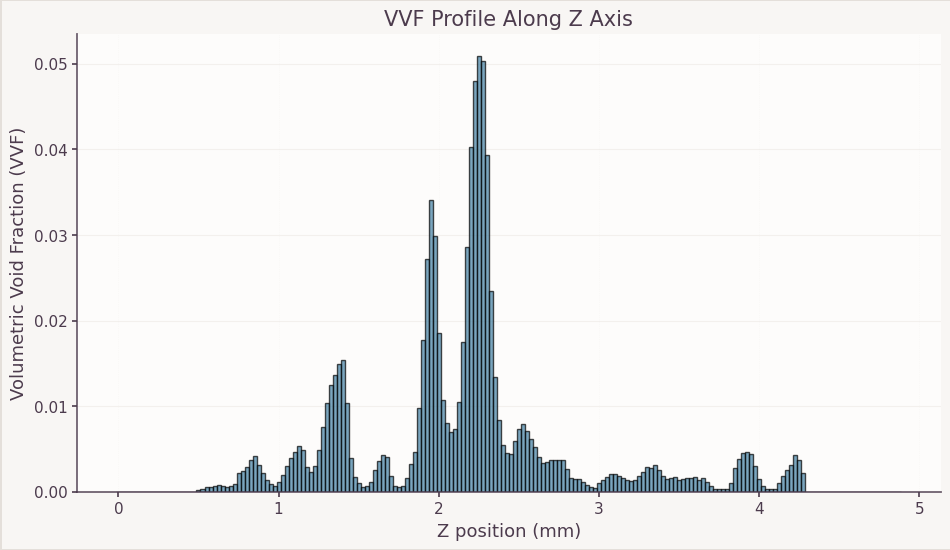

In [38]:
z_pore_count = np.count_nonzero(onlypores_volume, axis=(1,2))
z_material_count = np.count_nonzero(sample_mask, axis=(1,2))
z_volfraction = z_pore_count / z_material_count
z_volfraction[z_material_count == 0] = 0  # Avoid division by zero

#plot z_volfraction vs z index * 0.025
plt.bar(np.arange(len(z_volfraction)) * 0.025, z_volfraction, width=0.025, color='#4281a4', alpha=0.7, edgecolor='black')
plt.xlabel('Z position (mm)', fontsize=13, color='#4c3b4d')
plt.ylabel('Volumetric Void Fraction (VVF)', fontsize=13, color='#4c3b4d')
plt.title('VVF Profile Along Z Axis', fontsize=15, color='#4c3b4d')
apply_plot_theme()
plt.savefig(figures_folder / 'vvf_profile_z_axis.pdf', bbox_inches='tight', dpi=300)
plt.show()